
# Анализ временного ряда потребления электроэнергии

Задача 1: подготовка собственного набора данных и проведение его предварительного анализа

В этом ноутбуке:
- описывается предметная задача
- проверяется структура и качество данных
- выполняется базовая подготовка временных меток
- проводится EDA временного ряда и анализ его свойств
- формулируется постановка задачи прогнозирования

Набор данных: `powerconsumption.csv`

В качестве основного целевого ряда для постановки задачи используется `PowerConsumption_Zone1`
Параллельно анализируются погодные признаки и связанные ряды потребления



## 1. Постановка задачи

Набор данных содержит измерения электропотребления и погодных признаков с частотой 1 запись каждые 10 минут

Предварительно формулируем задачу как краткосрочное прогнозирование временного ряда `PowerConsumption_Zone1` по историческим значениям целевого ряда и экзогенным факторам:
- температура
- влажность
- скорость ветра
- солнечная радиация


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use("default")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

DATA_PATH = Path("powerconsumption.csv")
DATA_PATH

WindowsPath('powerconsumption.csv')

## 2. Загрузка данных

In [2]:
df_raw = pd.read_csv(DATA_PATH)
display(df_raw.head())
print("Размер:", df_raw.shape)
print("\nКолонки:", df_raw.columns.tolist())
print("\nИнформация:")
df_raw.info()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


Размер: (52416, 9)

Колонки: ['Datetime', 'Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows', 'PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']

Информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Datetime                52416 non-null  object 
 1   Temperature             52416 non-null  float64
 2   Humidity                52416 non-null  float64
 3   WindSpeed               52416 non-null  float64
 4   GeneralDiffuseFlows     52416 non-null  float64
 5   DiffuseFlows            52416 non-null  float64
 6   PowerConsumption_Zone1  52416 non-null  float64
 7   PowerConsumption_Zone2  52416 non-null  float64
 8   PowerConsumption_Zone3  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB


In [3]:
overview = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "missing_count": df_raw.isna().sum().values,
    "missing_share_%": (df_raw.isna().mean().values * 100).round(4),
    "n_unique": df_raw.nunique().values
})
display(overview)

,column,dtype,missing_count,missing_share_%,n_unique
0,Datetime,object,0,0.0,52416
1,Temperature,float64,0,0.0,3437
2,Humidity,float64,0,0.0,4443
3,WindSpeed,float64,0,0.0,548
4,GeneralDiffuseFlows,float64,0,0.0,10504
5,DiffuseFlows,float64,0,0.0,10449
6,PowerConsumption_Zone1,float64,0,0.0,27709
7,PowerConsumption_Zone2,float64,0,0.0,29621
8,PowerConsumption_Zone3,float64,0,0.0,22838


## 3. Подготовка данных к анализу

Приведём временную метку к типу `datetime`, отсортируем ряд по времени и проверим:
- пропуски
- дубликаты
- равномерность временного шага
- границы периода наблюдений

In [4]:
df = df_raw.copy()

df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")
df = df.dropna(subset=["Datetime"]).drop_duplicates().sort_values("Datetime").reset_index(drop=True)

print("Пропуски:")
display(df.isna().sum())

print("Дубликаты:", df.duplicated().sum())
print("Границы периода наблюдений:", df["Datetime"].min(), "->", df["Datetime"].max())

dt_diff = df["Datetime"].diff().dropna()

Пропуски:


Datetime                  0
Temperature               0
Humidity                  0
WindSpeed                 0
GeneralDiffuseFlows       0
DiffuseFlows              0
PowerConsumption_Zone1    0
PowerConsumption_Zone2    0
PowerConsumption_Zone3    0
dtype: int64

Дубликаты: 0
Границы периода наблюдений: 2017-01-01 00:00:00 -> 2017-12-30 23:50:00


In [5]:
# Проверка равномерности сетки 10 минут
expected_freq = pd.Timedelta(minutes=10)
irregular_points = (df["Datetime"].diff().dropna() != expected_freq).sum()
print(f"Количество нерегулярных интервалов: {irregular_points}")

Количество нерегулярных интервалов: 0


In [6]:
df = df.set_index("Datetime")

# Дополнительные календарные признаки для EDA
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)

display(df.head())

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,hour,dayofweek,month,is_weekend
Datetime,,,,,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,0,6,1,1
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,0,6,1,1
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,0,6,1,1
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,0,6,1,1
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,0,6,1,1



## 4. Краткое описание признаков

Целевой ряд
`PowerConsumption_Zone1` - потребление электроэнергии в первой зоне

Внешние признаки
- `Temperature` - температура
- `Humidity` - влажность
- `WindSpeed` - скорость ветра
- `GeneralDiffuseFlows` - общий поток рассеянной радиации
- `DiffuseFlows` - поток диффузного излучения

Дополнительные ряды
`PowerConsumption_Zone2` и `PowerConsumption_Zone3` полезны для анализа взаимной динамики, но в базовой постановке прогнозирования их лучше не использовать как признаки, чтобы не создавать риск утечки информации при прогнозе будущих значений

In [7]:
summary = df.drop(columns=["hour", "dayofweek", "month", "is_weekend"]).describe().T
display(summary)

,count,mean,std,min,25%,50%,75%,max
Temperature,52416.0,18.810024,5.815476,3.247000,14.410000,18.780000,22.890000,40.01000
Humidity,52416.0,68.259518,15.551177,11.340000,58.310000,69.860000,81.400000,94.80000
WindSpeed,52416.0,1.959489,2.348862,0.050000,0.078000,0.086000,4.915000,6.48300
GeneralDiffuseFlows,52416.0,182.696614,264.400960,0.004000,0.062000,5.035500,319.600000,1163.00000
DiffuseFlows,52416.0,75.028022,124.210949,0.011000,0.122000,4.456000,101.000000,936.00000
PowerConsumption_Zone1,52416.0,32344.970564,7130.562564,13895.696200,26310.668692,32265.920340,37309.018185,52204.39512
PowerConsumption_Zone2,52416.0,21042.509082,5201.465892,8560.081466,16980.766032,20823.168405,24713.717520,37408.86076
PowerConsumption_Zone3,52416.0,17835.406218,6622.165099,5935.174070,13129.326630,16415.117470,21624.100420,47598.32636


## 5. Базовый EDA временного ряда

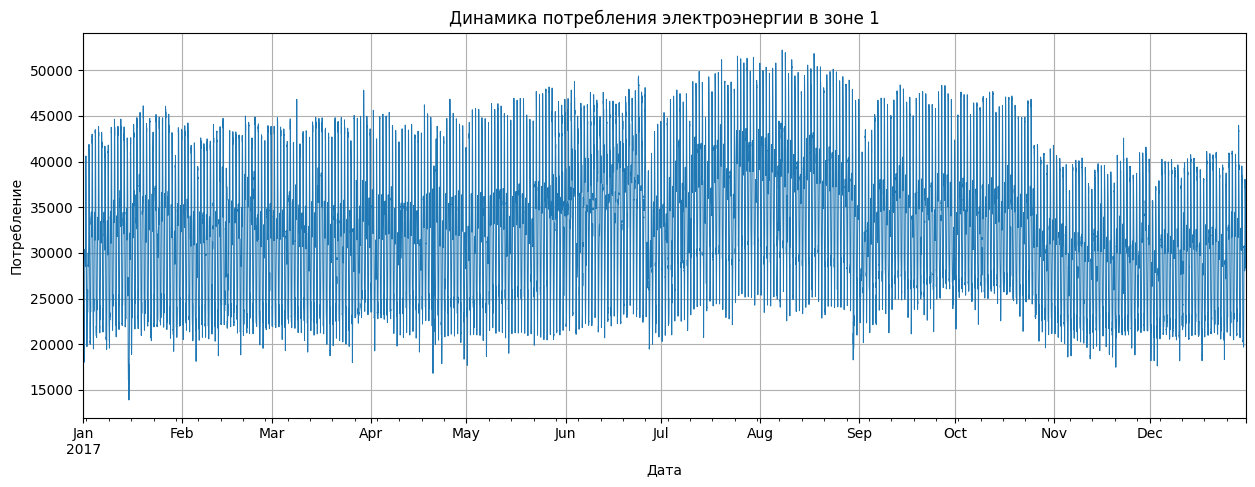

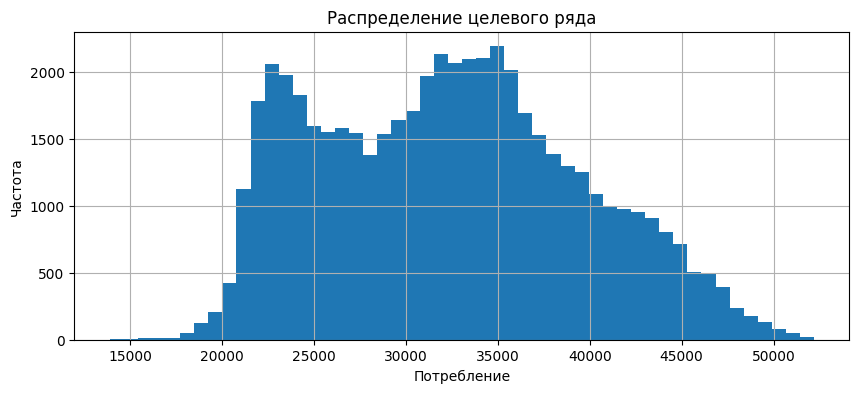

In [8]:
target = "PowerConsumption_Zone1"

fig, ax = plt.subplots(figsize=(15, 5))
df[target].plot(ax=ax, linewidth=0.7)
ax.set_title("Динамика потребления электроэнергии в зоне 1")
ax.set_xlabel("Дата")
ax.set_ylabel("Потребление")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
df[target].hist(bins=50, ax=ax)
ax.set_title("Распределение целевого ряда")
ax.set_xlabel("Потребление")
ax.set_ylabel("Частота")
plt.show()

In [9]:
# Сводка по целевому ряду
target_stats = df[target].agg(["mean", "median", "std", "min", "max", "skew", "kurt"])
display(target_stats.to_frame(name=target))

,PowerConsumption_Zone1
mean,32344.970564
median,32265.920340
std,7130.562564
min,13895.696200
max,52204.395120
skew,0.228864
kurt,-0.754054


## 6. Анализ сезонности и календарных эффектов

Для временного ряда с 10-минутной частотой удобно проверять:
- средние значения по часу суток
- средние значения по дню недели
- средние значения по месяцу
- наличие внутрисуточной и недельной сезонности

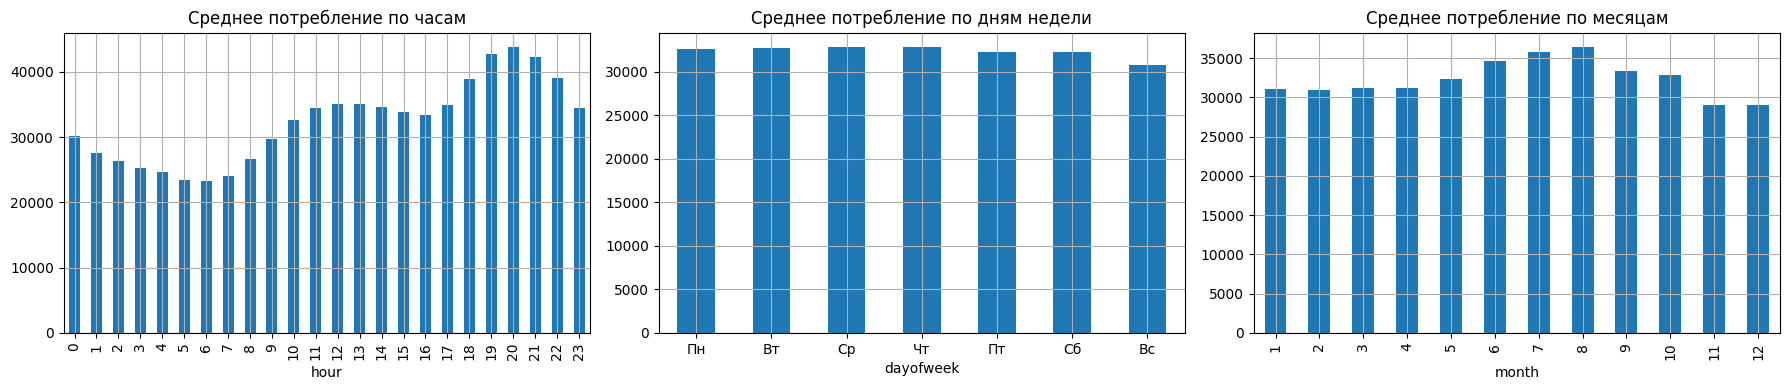

In [10]:
hour_profile = df.groupby("hour")[target].mean()
dow_profile = df.groupby("dayofweek")[target].mean()
month_profile = df.groupby("month")[target].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

hour_profile.plot(kind="bar", ax=axes[0])
axes[0].set_title("Среднее потребление по часам")

dow_profile.plot(kind="bar", ax=axes[1])
axes[1].set_title("Среднее потребление по дням недели")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"], rotation=0)

month_profile.plot(kind="bar", ax=axes[2])
axes[2].set_title("Среднее потребление по месяцам")

plt.tight_layout()
plt.show()

In [11]:
# Усреднение до почасового ряда
hourly = df[[target, "Temperature", "Humidity", "WindSpeed", "GeneralDiffuseFlows", "DiffuseFlows"]].resample("H").mean()

display(hourly.head())
print("Размер почасового ряда:", hourly.shape)

,PowerConsumption_Zone1,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows
Datetime,,,,,,
2017-01-01 00:00:00,29197.974683,6.196833,75.066667,0.081833,0.063500,0.098833
2017-01-01 01:00:00,24657.215190,5.548833,77.583333,0.082000,0.056833,0.112500
2017-01-01 02:00:00,22083.037973,5.054333,78.933333,0.082333,0.063000,0.129167
2017-01-01 03:00:00,20811.139240,5.004333,77.083333,0.082833,0.059833,0.141000
2017-01-01 04:00:00,20475.949367,5.097667,74.050000,0.082333,0.058000,0.122833


Размер почасового ряда: (8736, 6)


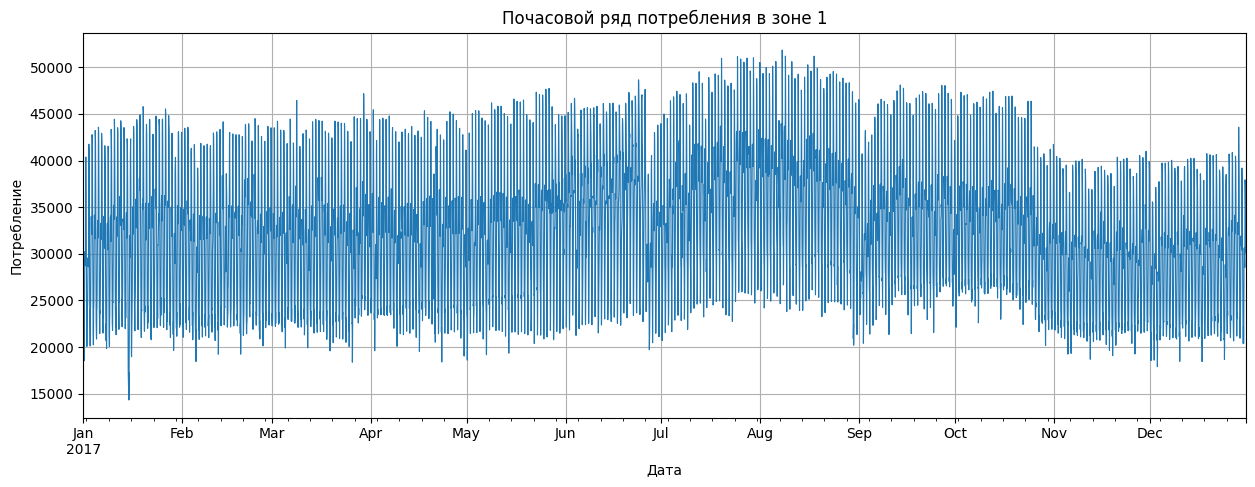

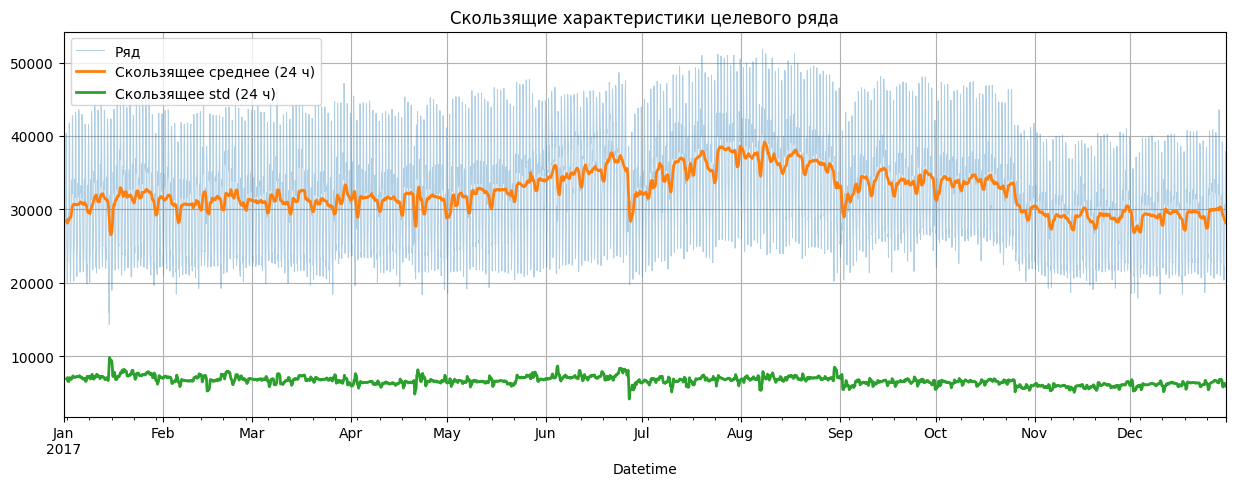

In [12]:
fig, ax = plt.subplots(figsize=(15, 5))
hourly[target].plot(ax=ax, linewidth=0.8)
ax.set_title("Почасовой ряд потребления в зоне 1")
ax.set_xlabel("Дата")
ax.set_ylabel("Потребление")
plt.show()

# Скользящие характеристики
roll = hourly[target].rolling(window=24)
fig, ax = plt.subplots(figsize=(15, 5))
hourly[target].plot(ax=ax, alpha=0.35, linewidth=0.7, label="Ряд")
roll.mean().plot(ax=ax, linewidth=2, label="Скользящее среднее (24 ч)")
roll.std().plot(ax=ax, linewidth=2, label="Скользящее std (24 ч)")
ax.legend()
ax.set_title("Скользящие характеристики целевого ряда")
plt.show()

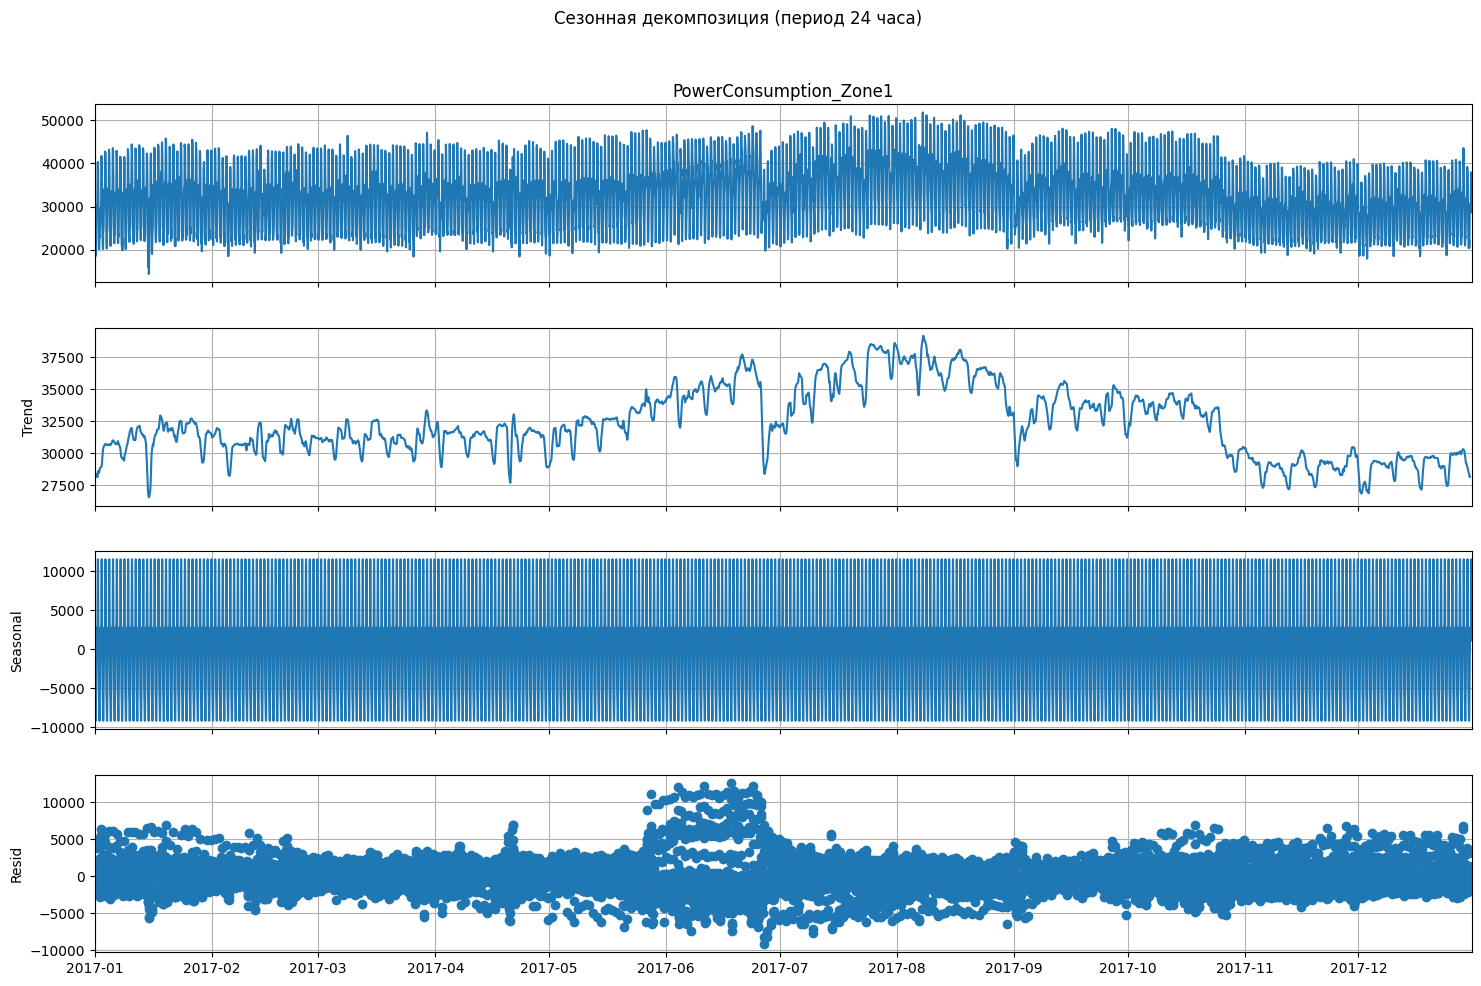

In [13]:
# Сезонная декомпозиция дневная сезонность на почасовом ряду
decomp = seasonal_decompose(hourly[target].dropna(), model="additive", period=24)

fig = decomp.plot()
fig.set_size_inches(15, 10)
plt.suptitle("Сезонная декомпозиция (период 24 часа)", y=1.02)
plt.show()

## 7. Проверка стационарности

Проверим:
- исходный ряд
- ряд после перехода к почасовому усреднению
- разности ряда

Используем тест Дики-Фуллера

In [14]:
def adf_report(series, name):
    series = pd.Series(series).dropna()
    stat, pvalue, _, _, crit, _ = adfuller(series, autolag="AIC")
    return pd.Series({
        "series": name,
        "adf_stat": stat,
        "p_value": pvalue,
        "n_obs": len(series),
        "stationary_5pct": pvalue < 0.05,
        "crit_1%": crit["1%"],
        "crit_5%": crit["5%"],
        "crit_10%": crit["10%"],
    })

adf_table = pd.DataFrame([
    adf_report(hourly[target], "hourly_target"),
    adf_report(hourly[target].diff(), "hourly_diff1"),
    adf_report(hourly[target].diff(24), "hourly_diff24"),
])

display(adf_table)

,series,adf_stat,p_value,n_obs,stationary_5pct,crit_1%,crit_5%,crit_10%
0,hourly_target,-4.445856,2.460164e-04,8736,True,-3.431102,-2.861872,-2.566947
1,hourly_diff1,-21.617795,0.000000e+00,8735,True,-3.431102,-2.861872,-2.566947
2,hourly_diff24,-18.333390,2.253489e-30,8712,True,-3.431103,-2.861873,-2.566947



## 8. Связь целевого ряда с внешними факторами

Посмотрим на корреляции между переменными и на совместную динамику целевого ряда с погодными признаками


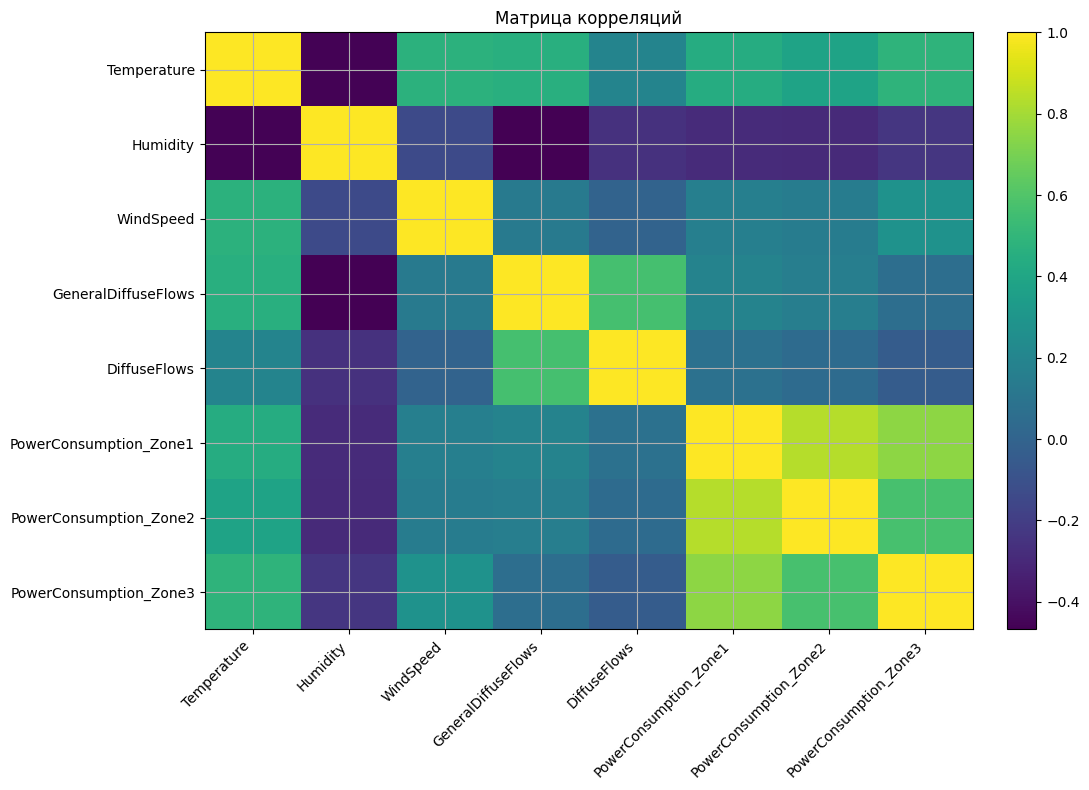

In [15]:
corr_cols = ["Temperature", "Humidity", "WindSpeed", "GeneralDiffuseFlows", "DiffuseFlows",
             "PowerConsumption_Zone1", "PowerConsumption_Zone2", "PowerConsumption_Zone3"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(corr.values, aspect="auto")
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
ax.set_title("Матрица корреляций")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

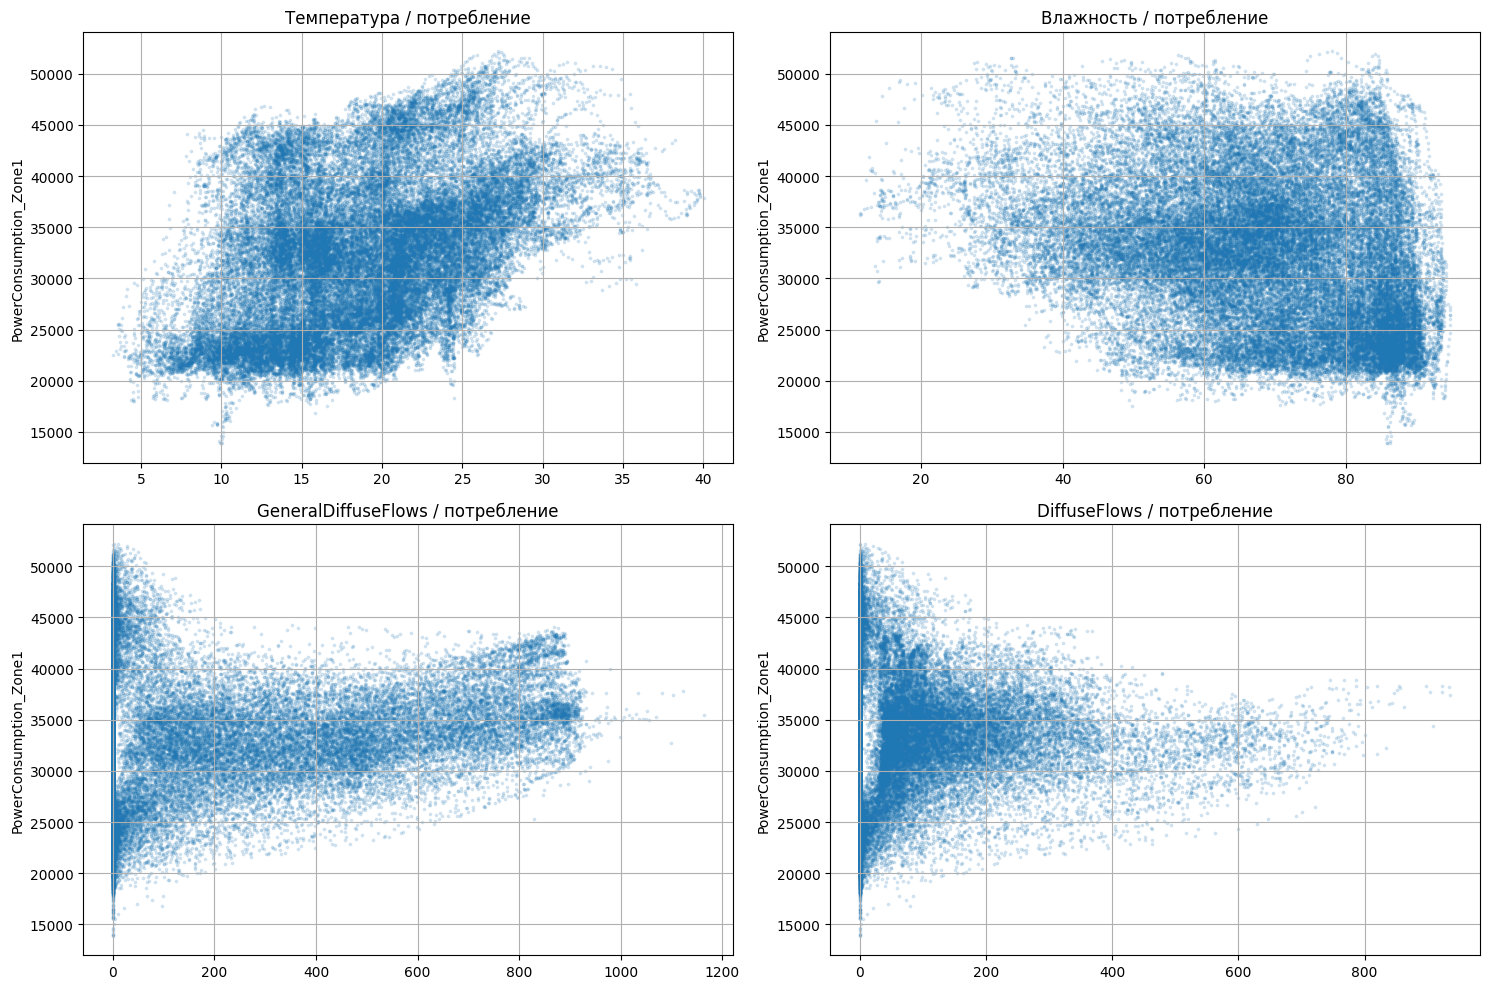

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].scatter(df["Temperature"], df[target], s=3, alpha=0.15)
axes[0, 0].set_title("Температура / потребление")

axes[0, 1].scatter(df["Humidity"], df[target], s=3, alpha=0.15)
axes[0, 1].set_title("Влажность / потребление")

axes[1, 0].scatter(df["GeneralDiffuseFlows"], df[target], s=3, alpha=0.15)
axes[1, 0].set_title("GeneralDiffuseFlows / потребление")

axes[1, 1].scatter(df["DiffuseFlows"], df[target], s=3, alpha=0.15)
axes[1, 1].set_title("DiffuseFlows / потребление")

for ax in axes.ravel():
    ax.set_xlabel("")
    ax.set_ylabel("PowerConsumption_Zone1")

plt.tight_layout()
plt.show()

## 9. Автоматизированная подготовка данных

Ниже формируется таблица с календарными признаками и сохраняется подготовленная версия датасета

In [17]:
prepared = df.reset_index().copy()

prepared = prepared[[
    "Datetime",
    "Temperature",
    "Humidity",
    "WindSpeed",
    "GeneralDiffuseFlows",
    "DiffuseFlows",
    "PowerConsumption_Zone1",
    "PowerConsumption_Zone2",
    "PowerConsumption_Zone3",
    "hour",
    "dayofweek",
    "month",
    "is_weekend",
]]

output_path = Path("powerconsumption_prepared_task1.csv")
prepared.to_csv(output_path, index=False)
print("Путь сохранения:", output_path.resolve())
display(prepared.head())

Путь сохранения: C:\Users\DragonSlayer\OneDrive\Рабочий стол\PowerComs_AVR\powerconsumption_prepared_task1.csv


,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,hour,dayofweek,month,is_weekend
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,0,6,1,1
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,0,6,1,1
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,0,6,1,1
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,0,6,1,1
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,0,6,1,1


## 10. Выводы по EDA

1. Данные имеют высокую частоту измерения - 1 точка каждые 10 минут
2. Пропусков и дублей в исходном наборе не обнаружено
3. Ряд обладает выраженной временной структурой и сезонностью
4. Погодные признаки потенциально полезны для прогноза
5. Для дальнейшей работы целесообразно строить модели краткосрочного прогноза `PowerConsumption_Zone1` с использованием исторических лагов и внешних факторов

### Что подготовлено
- очищенный и отсортированный временной ряд
- календарные признаки
- базовый набор для EDA
- понимание сезонности и стационарности ряда

# Задача 2. Статистические методы прогнозирования временного ряда

Цель: сравнить методы из `statsforecast`, выбрать рабочую статистическую модель по backtesting и hold-out, а также проверить качество остатков и интервального прогноза

- горизонт оценки: 7 суток
- сезонность для часового ряда: 24

## 1. Окружение и импорт библиотек

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsforecast import StatsForecast
from statsforecast.utils import ConformalIntervals
from statsforecast.models import (
    ARIMA,
    AutoARIMA,
    SeasonalExponentialSmoothing,
    AutoETS,
    Theta,
    AutoTheta,
    SeasonalNaive,
)

from prophet import Prophet

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = True

OUT_DIR = Path("task2_outputs")
OUT_DIR.mkdir(exist_ok=True)

Importing plotly failed. Interactive plots will not work.


## 2. Подготовка данных

In [19]:
raw = pd.read_csv(DATA_PATH)
raw["Datetime"] = pd.to_datetime(raw["Datetime"], errors="coerce")

hourly = (
    raw[["Datetime", "PowerConsumption_Zone1"]]
    .dropna()
    .drop_duplicates()
    .set_index("Datetime")
    .resample("H")
    .mean()
    .rename(columns={"PowerConsumption_Zone1": "y"})
    .reset_index()
    .rename(columns={"Datetime": "ds"})
)

hourly["unique_id"] = "zone1"
hourly = hourly[["unique_id", "ds", "y"]].sort_values("ds").reset_index(drop=True)

display(hourly.head())
print("Размер:", hourly.shape)
print("Границы периода наблюдений:", hourly["ds"].min(), "->", hourly["ds"].max())

hourly.to_csv(OUT_DIR / "task2_zone1_hourly.csv", index=False)

,unique_id,ds,y
0,zone1,2017-01-01 00:00:00,29197.974683
1,zone1,2017-01-01 01:00:00,24657.215190
2,zone1,2017-01-01 02:00:00,22083.037973
3,zone1,2017-01-01 03:00:00,20811.139240
4,zone1,2017-01-01 04:00:00,20475.949367


Размер: (8736, 3)
Границы периода наблюдений: 2017-01-01 00:00:00 -> 2017-12-30 23:00:00


## 3. Краткая проверка ряда

Смотрим на уровень ряда, автокорреляцию и стационарность

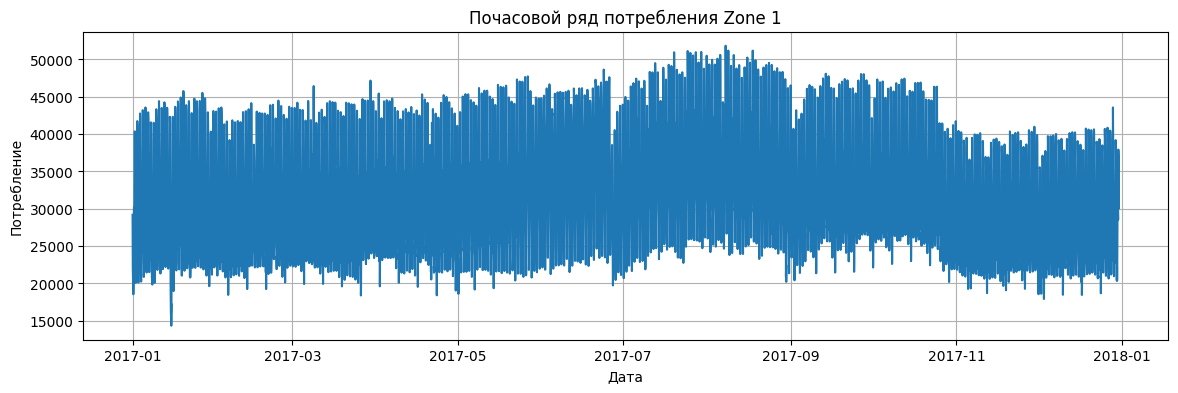

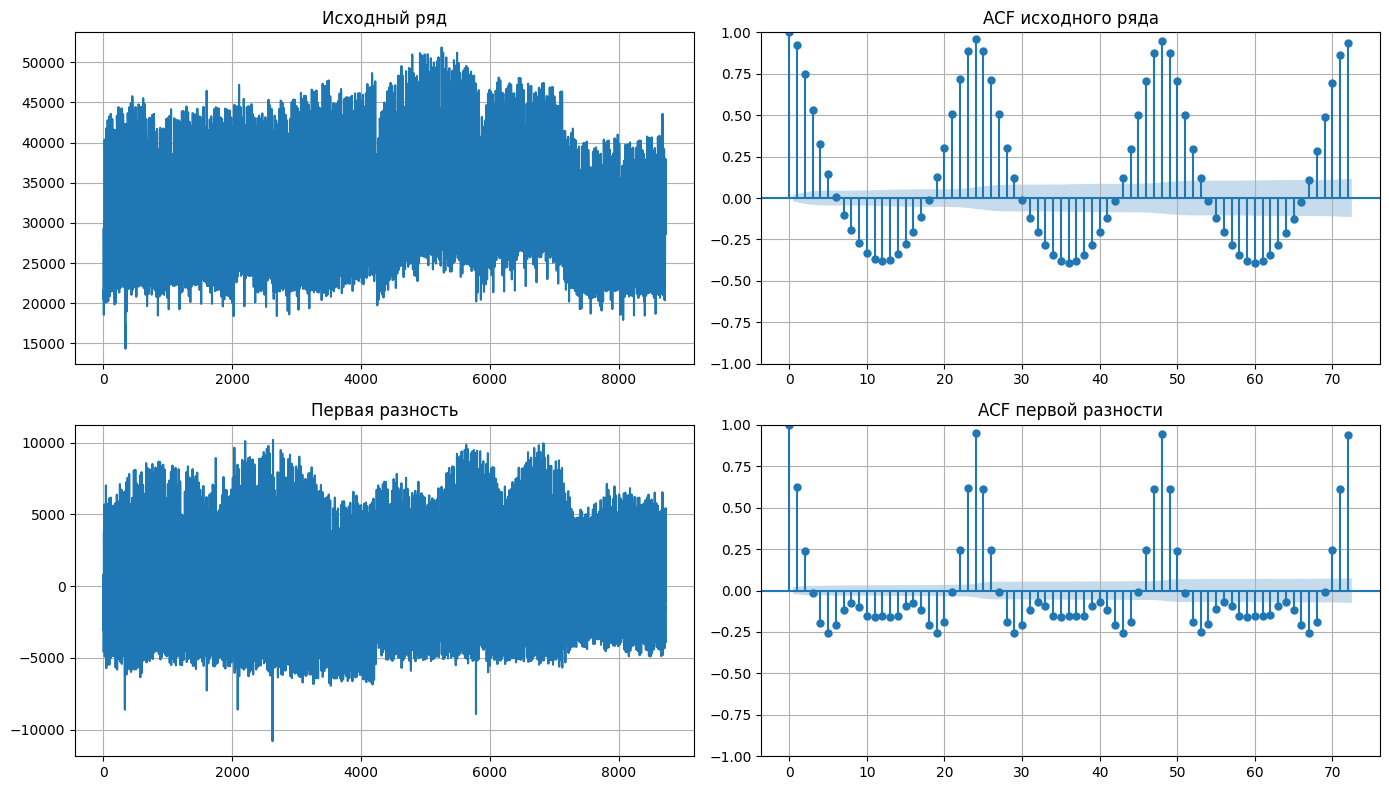

ADF исходного ряда:
{'stat': -4.445856092337916, 'p_value': 0.00024601641924987304}
ADF первой разности:
{'stat': -21.617795168175405, 'p_value': 0.0}


In [20]:
series = hourly["y"]

fig, ax = plt.subplots()
ax.plot(hourly["ds"], hourly["y"])
ax.set_title("Почасовой ряд потребления Zone 1")
ax.set_xlabel("Дата")
ax.set_ylabel("Потребление")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(series.values)
axes[0, 0].set_title("Исходный ряд")

plot_acf(series, lags=72, ax=axes[0, 1])
axes[0, 1].set_title("ACF исходного ряда")

diff1 = series.diff().dropna()
axes[1, 0].plot(diff1.values)
axes[1, 0].set_title("Первая разность")

plot_acf(diff1, lags=72, ax=axes[1, 1])
axes[1, 1].set_title("ACF первой разности")

plt.tight_layout()
plt.show()

adf_orig = adfuller(series.dropna(), autolag="AIC")
adf_diff = adfuller(diff1.dropna(), autolag="AIC")

print("ADF исходного ряда:")
print({"stat": adf_orig[0], "p_value": adf_orig[1]})
print("ADF первой разности:")
print({"stat": adf_diff[0], "p_value": adf_diff[1]})

## 4. Схема оценки

Используем один и тот же горизонт:
- h = 168 часов
- для backtesting: 3 скользящих окна
- для финальной проверки: последний отрезок ряда как hold-out

Для моделей из statsforecast используем одинаковую сезонность season_length = 24

In [21]:
SEASON_LENGTH = 24 # Суточная сезонность для почасового ряда
H = 24 # Горизонт прогнозирования - 24 часа

hourly_df_small = hourly.tail(24 * 90).copy()
train = hourly_df_small.iloc[:-H]
test = hourly_df_small.iloc[-H:]

print("Train:", train.shape)
print("Test :", test.shape)
print("Train range:", train["ds"].min(), "->", train["ds"].max())
print("Test  range:", test["ds"].min(), "->", test["ds"].max())

prediction_intervals = ConformalIntervals(h=H, n_windows=3)

Train: (2136, 3)
Test : (24, 3)
Train range: 2017-10-02 00:00:00 -> 2017-12-29 23:00:00
Test  range: 2017-12-30 00:00:00 -> 2017-12-30 23:00:00


## 5. Набор моделей

- ARIMA
- AutoARIMA
- SeasonalExponentialSmoothing
- AutoETS
- Theta
- AutoTheta
- SeasonalNaive

In [22]:
stat_models = [
    ARIMA(order=(1, 1, 1)),
    AutoARIMA(season_length=SEASON_LENGTH),
    SeasonalExponentialSmoothing(alpha=0.8, season_length=SEASON_LENGTH),
    AutoETS(season_length=SEASON_LENGTH),
    Theta(season_length=SEASON_LENGTH, decomposition_type="additive"),
    AutoTheta(season_length=SEASON_LENGTH),
    SeasonalNaive(season_length=SEASON_LENGTH),
]

stat_model_names = [
    "ARIMA",
    "AutoARIMA",
    "SeasonalES",
    "AutoETS",
    "Theta",
    "AutoTheta",
    "SeasonalNaive",
]

sf = StatsForecast(
    models=stat_models,
    freq="H",
    n_jobs=-1
)

## 6. Backtesting на статистических моделях

Оцениваем качество на скользящих окнах и сравниваем модели по MAE, RMSE, MAPE, sMAPE, MASE и покрытию 95% интервала.

In [23]:
def metrics_table(y_true, pred_df, model_cols):
    rows = []
    y_true = np.asarray(y_true)

    for model in model_cols:
        pred = np.asarray(pred_df[model])
        rows.append({
            "model": model,
            "MAE": mean_absolute_error(y_true, pred),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, pred))),
            "MAPE_%": float(np.nanmean(
                np.abs((y_true - pred) / np.where(y_true == 0, np.nan, y_true))
            ) * 100),
        })

    return pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)

cv = sf.cross_validation(
    df=train,
    h=H,
    n_windows=3,
    step_size=H,
    level=[95],
    prediction_intervals=prediction_intervals,
)

display(cv.head())
print("CV shape:", cv.shape)

cv_metrics = metrics_table(
    y_true=cv["y"],
    pred_df=cv,
    model_cols=stat_model_names
)
cv_metrics = cv_metrics.sort_values("RMSE").reset_index(drop=True)
display(cv_metrics)

cv_metrics.to_csv(OUT_DIR / "task2_backtesting_metrics.csv", index=False)

,unique_id,ds,cutoff,y,ARIMA,ARIMA-lo-95,ARIMA-hi-95,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-hi-95,...,AutoETS-hi-95,Theta,Theta-lo-95,Theta-hi-95,AutoTheta,AutoTheta-lo-95,AutoTheta-hi-95,SeasonalNaive,SeasonalNaive-lo-95,SeasonalNaive-hi-95
0,zone1,2017-12-27 00:00:00,2017-12-26 23:00:00,25451.964512,26596.180327,25027.277389,28165.083266,25517.584707,25296.752299,25738.417116,...,27985.270931,25817.553292,25426.554597,26208.551987,25899.522881,25518.756386,26280.289376,25777.439797,25108.871989,26446.007605
1,zone1,2017-12-27 01:00:00,2017-12-26 23:00:00,22827.883398,25435.966483,21831.362209,29040.570756,22936.009138,22542.101342,23329.916934,...,25491.823819,23711.989854,22378.986270,25044.993438,23833.761606,22563.964120,25103.559093,23274.017742,23175.031680,23373.003803
2,zone1,2017-12-27 02:00:00,2017-12-26 23:00:00,21465.145753,24939.768078,19890.302825,29989.233330,21624.806291,20727.175784,22522.436799,...,24181.945816,22548.106510,20501.393917,24594.819104,22688.949612,20723.663759,24654.235466,22113.054498,21517.617235,22708.491762
3,zone1,2017-12-27 03:00:00,2017-12-26 23:00:00,20838.529785,24727.554736,19344.144167,30110.965306,21020.822590,20336.689485,21704.955695,...,23731.049416,22008.883947,19991.117136,24026.650757,22155.772423,20231.581486,24079.963361,21455.006337,20841.825097,22068.187576
4,zone1,2017-12-27 04:00:00,2017-12-26 23:00:00,20658.048163,24636.795673,19158.666588,30114.924758,20785.097828,20114.118476,21456.077180,...,23530.099110,22041.768845,19831.472414,24252.065275,22176.823199,20062.070725,24291.575672,21013.941698,20385.424589,21642.458808


CV shape: (72, 25)


,model,MAE,RMSE,MAPE_%
0,SeasonalES,769.031775,1090.468709,2.481265
1,AutoETS,865.330069,1104.048577,2.928209
2,AutoARIMA,868.532860,1135.462385,2.751104
3,SeasonalNaive,794.437403,1146.627245,2.560708
4,Theta,1055.358899,1311.949809,3.570591
5,AutoTheta,1109.686826,1363.604166,3.736421
6,ARIMA,6773.724770,8351.853631,20.571733


## 7. Финальное сравнение на hold-out

После backtesting строим прогноз на последний отрезок и сравниваем модели на одинаковом тестовом окне

In [24]:
stat_forecast = sf.forecast(df=train, h=H, level=[95])
display(stat_forecast.head())

holdout_metrics = metrics_table(
    y_true=test["y"],
    pred_df=stat_forecast,
    model_cols=stat_model_names,
)

holdout_metrics = pd.concat([holdout_metrics], ignore_index=True)
holdout_metrics = holdout_metrics.sort_values("RMSE").reset_index(drop=True)

display(holdout_metrics)

holdout_metrics.to_csv(OUT_DIR / "task2_holdout_metrics.csv", index=False)

,unique_id,ds,ARIMA,ARIMA-lo-95,ARIMA-hi-95,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-hi-95,SeasonalES,SeasonalES-lo-95,...,AutoETS-hi-95,Theta,Theta-lo-95,Theta-hi-95,AutoTheta,AutoTheta-lo-95,AutoTheta-hi-95,SeasonalNaive,SeasonalNaive-lo-95,SeasonalNaive-hi-95
0,zone1,2017-12-30 00:00:00,28328.133127,27218.333599,29437.932655,26684.668050,26323.505629,27045.830471,26069.376062,25620.327534,...,26651.621055,26790.017208,26429.062107,27150.972310,26748.480165,26315.970093,27180.990237,26161.723698,25755.513307,26567.934090
1,zone1,2017-12-30 01:00:00,27479.506191,24968.270842,29990.741540,24112.202985,23410.055330,24814.350639,23829.657791,23254.245825,...,24172.779604,24676.895650,23848.788411,25505.002889,24605.451941,23672.051712,25538.852171,23941.191380,23298.098859,24584.283901
2,zone1,2017-12-30 02:00:00,27118.117635,23713.083463,30523.151807,22540.453514,21961.835535,23119.071493,22248.777327,21652.054569,...,22793.007019,23503.529663,22445.024148,24562.035179,23412.358796,22232.850351,24591.867242,22320.912548,21680.481623,22961.343474
3,zone1,2017-12-30 03:00:00,26964.219989,23120.701279,30807.738699,21712.218071,21372.029413,22052.406729,21417.138038,20831.893531,...,22144.941228,22957.464853,21779.256919,24135.672786,22854.110753,21557.157096,24151.064410,21485.424588,20902.154628,22068.694549
4,zone1,2017-12-30 04:00:00,26898.682536,22922.166487,30875.198584,21340.138321,20835.279741,21844.996901,20980.652073,20541.920167,...,21919.937098,22982.200541,21284.209079,24680.192003,22867.678112,21183.895117,24551.461106,20952.091257,20448.035488,21456.147025


,model,MAE,RMSE,MAPE_%
0,SeasonalNaive,1087.959442,1232.833305,4.103270
1,AutoETS,1197.741321,1412.074751,4.184127
2,SeasonalES,1271.521393,1446.690109,4.668811
3,AutoARIMA,1491.164010,1623.652147,5.459459
4,AutoTheta,2253.273181,2424.102271,8.302821
5,Theta,2320.195870,2492.321728,8.580210
6,ARIMA,5261.952613,5962.350020,18.970999


## 8. Выбор модели

Выбираем модель с минимальной ошибкой на backtesting

Лучшая модель по CV RMSE: SeasonalES
Лучшая модель по hold-out RMSE: SeasonalNaive


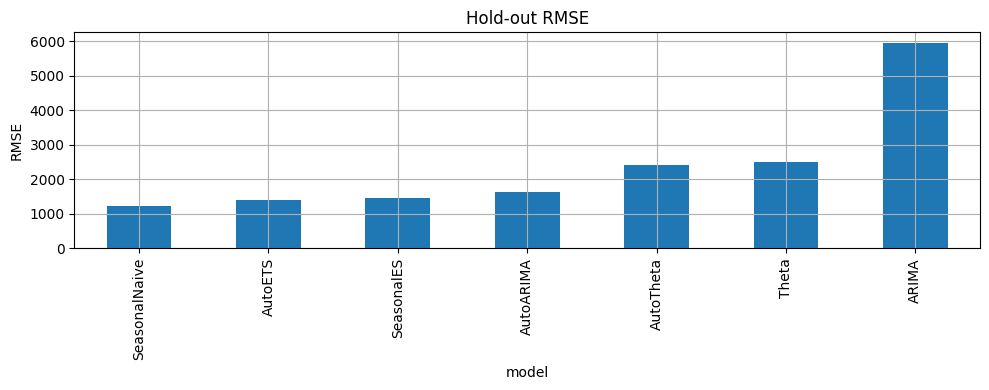

In [25]:
best_stat_model = cv_metrics.iloc[0]["model"]
print("Лучшая модель по CV RMSE:", best_stat_model)

best_holdout = holdout_metrics.iloc[0]["model"]
print("Лучшая модель по hold-out RMSE:", best_holdout)

fig, ax = plt.subplots(figsize=(10, 4))
holdout_metrics.set_index("model")["RMSE"].sort_values().plot(kind="bar", ax=ax)
ax.set_title("Hold-out RMSE")
ax.set_ylabel("RMSE")
plt.tight_layout()
plt.show()

## 9. Прогноз лучшей статистической модели

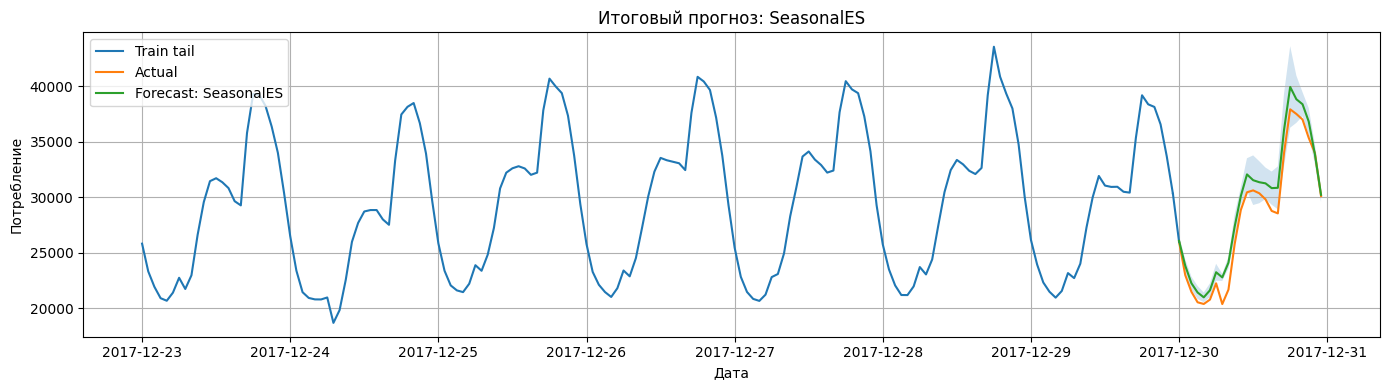

In [26]:
from statsforecast.utils import ConformalIntervals

prediction_intervals = ConformalIntervals(
    h=H,
    n_windows=3
)

best_model_map = {
    "ARIMA": ARIMA(order=(1, 1, 1)),
    "AutoARIMA": AutoARIMA(season_length=SEASON_LENGTH),
    "SeasonalES": SeasonalExponentialSmoothing(alpha=0.8, season_length=SEASON_LENGTH),
    "AutoETS": AutoETS(season_length=SEASON_LENGTH),
    "Theta": Theta(season_length=SEASON_LENGTH, decomposition_type="additive"),
    "AutoTheta": AutoTheta(season_length=SEASON_LENGTH),
    "SeasonalNaive": SeasonalNaive(season_length=SEASON_LENGTH),
}

chosen_model = best_stat_model if best_stat_model in best_model_map else "AutoETS"

chosen_sf = StatsForecast(
    models=[best_model_map[chosen_model]],
    freq="H",
    n_jobs=-1
)

chosen_fcst = chosen_sf.forecast(
    df=train,
    h=H,
    level=[95],
    prediction_intervals=prediction_intervals
)

chosen_col = [c for c in chosen_fcst.columns if c not in ["unique_id", "ds"]][0]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train["ds"].tail(7 * 24), train["y"].tail(7 * 24), label="Train tail")
ax.plot(test["ds"], test["y"], label="Actual")
ax.plot([train["ds"].iloc[-1], test["ds"].iloc[0]], [train["y"].iloc[-1], test["y"].iloc[0]], color="C0")

ax.plot(chosen_fcst["ds"], chosen_fcst[chosen_col], label=f"Forecast: {chosen_model}")

lo_col = f"{chosen_col}-lo-95"
hi_col = f"{chosen_col}-hi-95"
if lo_col in chosen_fcst.columns and hi_col in chosen_fcst.columns:
    ax.fill_between(chosen_fcst["ds"], chosen_fcst[lo_col], chosen_fcst[hi_col], alpha=0.2)

ax.set_title(f"Итоговый прогноз: {chosen_model}")
ax.set_xlabel("Дата")
ax.set_ylabel("Потребление")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Анализ остатков лучшей статистической модели

CV колонки: ['unique_id', 'ds', 'cutoff', 'y', 'SeasonalES', 'SeasonalES-lo-95', 'SeasonalES-hi-95']
Остаточный mean: -342.8669351712585
Остаточный std : 1219.2006290372456


,lb_stat,lb_pvalue
24,134.398953,2.464285e-17


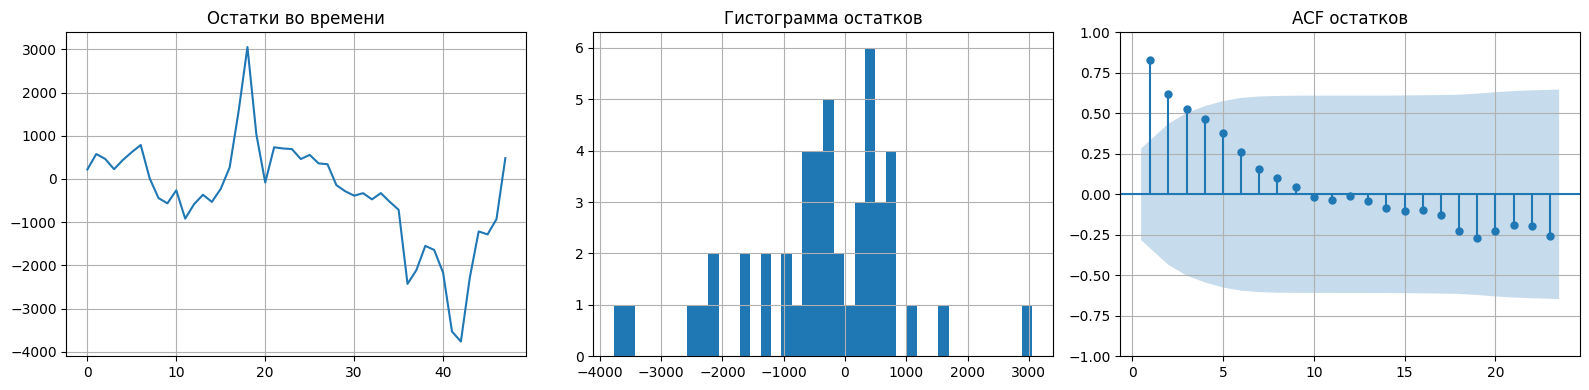

In [27]:
prediction_intervals = ConformalIntervals(
    h=H,
    n_windows=2
)

cv_res = chosen_sf.cross_validation(
    df=train,
    h=H,
    n_windows=2,
    step_size=H,
    level=[95],
    prediction_intervals=prediction_intervals
)

print("CV колонки:", cv_res.columns.tolist())

model_cols = [
    c for c in cv_res.columns
    if c not in ["unique_id", "ds", "cutoff", "y"]
    and not c.endswith("-lo-95")
    and not c.endswith("-hi-95")
]

model_col = model_cols[0]

resid = (cv_res["y"] - cv_res[model_col]).dropna()

print("Остаточный mean:", float(np.nanmean(resid)))
print("Остаточный std :", float(np.nanstd(resid)))

lb = acorr_ljungbox(resid, lags=[24], return_df=True)
display(lb)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(resid.values)
axes[0].set_title("Остатки во времени")

axes[1].hist(resid, bins=40)
axes[1].set_title("Гистограмма остатков")

max_lag = min(47, len(resid) // 2 - 1)

plot_acf(
    resid,
    lags=max_lag,
    zero=False,
    ax=axes[2]
)

axes[2].set_title("ACF остатков")

plt.tight_layout()
plt.show()

## 11. Итог

- сравнили статистические модели на одном и том же горизонте
- использовали backtesting и hold-out
- проверили интервальный прогноз
- проанализировали остатки выбранной модели

Файл с подготовленными данными и таблицы метрик сохраняются в папку task2_outputs

# Задача 3. Data-driven анализ временного ряда: ML, DL и аномалии

В ноутбуке используется тот же целевой ряд `PowerConsumption_Zone1`, что и в предыдущих задачах.

**Цель:** сравнить 3 метода машинного обучения, 3 метода глубокого обучения и 3 метода выявления аномалий во временном ряду.

## 1. Окружение и импорт библиотек

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, IsolationForest

from statsmodels.tsa.seasonal import STL
from scipy.stats import median_abs_deviation

from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean

from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, RNN, NHITS

from lightgbm import LGBMRegressor

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = True

DATA_PATH = Path("powerconsumption.csv")
OUT_DIR = Path("task3_outputs")
OUT_DIR.mkdir(exist_ok=True)

## 2. Подготовка данных

Исходный 10-минутный ряд переводим в почасовую сетку и оставляем только Zone 1

In [29]:
raw = pd.read_csv(DATA_PATH)
raw["Datetime"] = pd.to_datetime(raw["Datetime"], errors="coerce")

hourly = (
    raw[["Datetime", "PowerConsumption_Zone1"]]
    .dropna()
    .drop_duplicates()
    .set_index("Datetime")
    .resample("H")
    .mean()
    .rename(columns={"PowerConsumption_Zone1": "y"})
    .reset_index()
    .rename(columns={"Datetime": "ds"})
)

hourly["unique_id"] = "zone1"
hourly = hourly[["unique_id", "ds", "y"]].sort_values("ds").reset_index(drop=True)

display(hourly.head())

,unique_id,ds,y
0,zone1,2017-01-01 00:00:00,29197.974683
1,zone1,2017-01-01 01:00:00,24657.215190
2,zone1,2017-01-01 02:00:00,22083.037973
3,zone1,2017-01-01 03:00:00,20811.139240
4,zone1,2017-01-01 04:00:00,20475.949367


## 3. Краткий обзор ряда

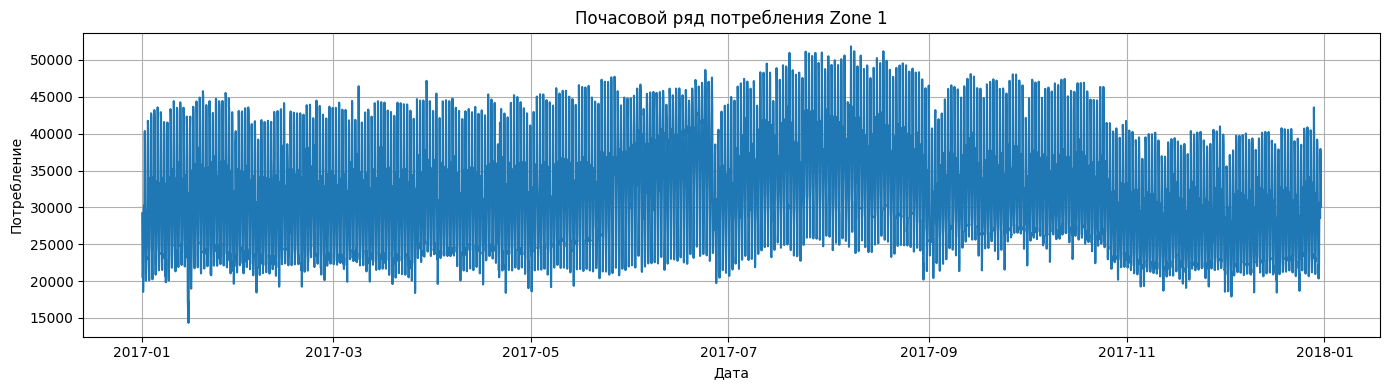

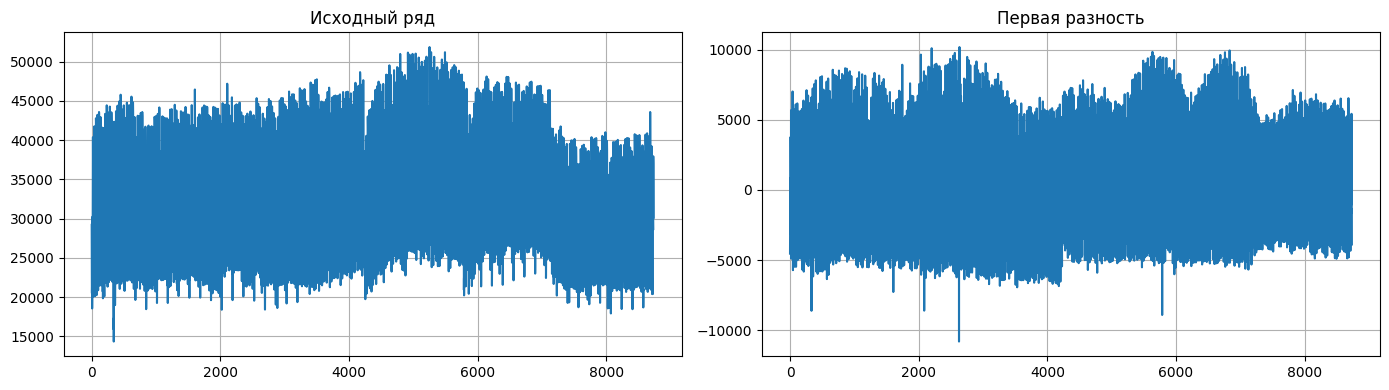

In [30]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(hourly["ds"], hourly["y"])
ax.set_title("Почасовой ряд потребления Zone 1")
ax.set_xlabel("Дата")
ax.set_ylabel("Потребление")
plt.tight_layout()
plt.show()

series = hourly["y"]
diff1 = series.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(series.values)
axes[0].set_title("Исходный ряд")

axes[1].plot(diff1.values)
axes[1].set_title("Первая разность")

plt.tight_layout()
plt.show()

## 4. Схема оценки

Используем один и тот же горизонт
- h = 24 часа
- hold-out — последний день ряда
- для ML-моделей дополнительно смотрим backtesting на скользящих окнах

Сезонность для часового ряда фиксируем на уровне 24

In [31]:
SEASON_LENGTH = 24
H = 24

train = hourly.iloc[:-H].copy()
test = hourly.iloc[-H:].copy()

print("Train:", train.shape)
print("Test :", test.shape)

Train: (8712, 3)
Test : (24, 3)


## 5. Feature engineering для MLForecast

Для машинного обучения строим признаки:
- лаги 1, 24, 48, 168
- скользящее среднее по суточному лагу
- календарные признаки: hour, dayofweek, month

Эти признаки помогают модели увидеть суточную и недельную сезонность

In [32]:
feature_view = MLForecast(
    models=[],
    freq="H",
    lags=[1, 24, 48, 168],
    lag_transforms={
        24: [RollingMean(window_size=24)],
        168: [RollingMean(window_size=24)],
    },
    date_features=["hour", "dayofweek", "month"],
)

feature_sample = feature_view.preprocess(train)
display(feature_sample.head())
print("Feature columns:", feature_sample.columns.tolist())

,unique_id,ds,y,lag1,lag24,lag48,lag168,rolling_mean_lag24_window_size24,rolling_mean_lag168_window_size24,hour,dayofweek,month
191,zone1,2017-01-08 23:00:00,30085.063293,35763.037975,31526.075950,31635.443038,30072.911392,30612.700422,28465.232067,23,6,1
192,zone1,2017-01-09 00:00:00,25735.696202,30085.063293,26633.924052,27193.924052,25303.291138,30589.367088,28302.953586,0,0,1
193,zone1,2017-01-09 01:00:00,22778.734177,25735.696202,23640.506328,23961.518987,22512.405062,30575.991561,28213.586497,1,0,1
194,zone1,2017-01-09 02:00:00,21659.746835,22778.734177,21817.721520,22588.354430,20945.822783,30543.881856,28166.202531,2,0,1
195,zone1,2017-01-09 03:00:00,20750.379747,21659.746835,20831.392407,21849.113925,20097.215188,30501.476793,28136.455696,3,0,1


Feature columns: ['unique_id', 'ds', 'y', 'lag1', 'lag24', 'lag48', 'lag168', 'rolling_mean_lag24_window_size24', 'rolling_mean_lag168_window_size24', 'hour', 'dayofweek', 'month']


## 6. Метрики качества

Для сравнения моделей используем MAE, RMSE и MAPE

In [33]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mape = np.nanmean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAPE_%": float(mape),
    }

def metrics_table(y_true, pred_df, model_cols):
    rows = []
    for model in model_cols:
        row = {"model": model}
        row.update(regression_metrics(y_true, pred_df[model]))
        rows.append(row)
    return pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)

## 7. Машинное обучение: 3 модели

Сравниваем:
- LinearRegression — линейный базовый вариант
- RandomForestRegressor — нелинейная модель на деревьях
- LightGBM — бустинг, обычно сильный для табличных признаков временного ряда

In [34]:
ml_models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42,
        verbosity=-1,
    ),
}

mlf = MLForecast(
    models=ml_models,
    freq="H",
    lags=[1, 24, 48, 168],
    lag_transforms={
        24: [RollingMean(window_size=24)],
        168: [RollingMean(window_size=24)],
    },
    date_features=["hour", "dayofweek", "month"],
)

mlf.fit(df=train)
ml_pred = mlf.predict(H)
display(ml_pred.head())

ml_eval = test.merge(ml_pred, on=["unique_id", "ds"], how="left")
ml_model_cols = [c for c in ml_pred.columns if c not in ["unique_id", "ds"]]

ml_metrics = metrics_table(ml_eval["y"], ml_eval, ml_model_cols)
display(ml_metrics)

ml_metrics.to_csv(OUT_DIR / "task3_ml_metrics.csv", index=False)

,unique_id,ds,LinearRegression,RandomForest,LightGBM
0,zone1,2017-12-30 00:00:00,26503.410789,26286.182725,26074.878136
1,zone1,2017-12-30 01:00:00,23822.972926,23769.678120,23685.346011
2,zone1,2017-12-30 02:00:00,22024.671253,22394.958066,22163.972242
3,zone1,2017-12-30 03:00:00,20914.310045,21168.876015,21151.876821
4,zone1,2017-12-30 04:00:00,20412.946756,20814.362561,20735.316294


,model,MAE,RMSE,MAPE_%
0,LightGBM,730.957009,863.086614,2.678672
1,LinearRegression,743.016215,903.750363,2.634367
2,RandomForest,832.004399,980.518956,3.011592


Best ML model: LightGBM


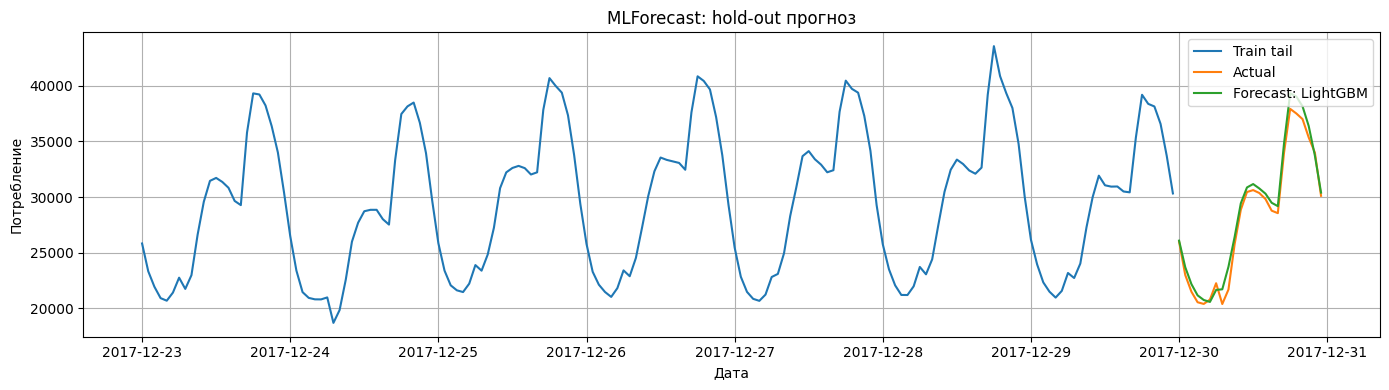

In [35]:
best_ml_model = ml_metrics.iloc[0]["model"]
print("Best ML model:", best_ml_model)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train["ds"].tail(7 * 24), train["y"].tail(7 * 24), label="Train tail")
ax.plot(test["ds"], test["y"], label="Actual")
ax.plot(ml_eval["ds"], ml_eval[best_ml_model], label=f"Forecast: {best_ml_model}")
ax.set_title("MLForecast: hold-out прогноз")
ax.set_xlabel("Дата")
ax.set_ylabel("Потребление")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Глубокое обучение: 3 модели

Сравниваем:
- RNN — простая рекуррентная сеть
- LSTM — сеть с памятью
- NHITS — современная архитектура для временных рядов

Чтобы снизить время обучения, используется короткий список моделей и ограниченное число шагов

In [36]:
nf_models = [
    RNN(h=H, input_size=168, max_steps=50),
    LSTM(h=H, input_size=168, max_steps=50),
    NHITS(h=H, input_size=168, max_steps=50),
]

nf = NeuralForecast(models=nf_models, freq="H")
nf.fit(df=train)
nf_pred = nf.predict()
display(nf_pred.head())

nf_eval = test.merge(nf_pred, on=["unique_id", "ds"], how="left")
nf_model_cols = [c for c in nf_pred.columns if c not in ["unique_id", "ds"]]

nf_metrics = metrics_table(nf_eval["y"], nf_eval, nf_model_cols)
display(nf_metrics)

nf_metrics.to_csv(OUT_DIR / "task3_dl_metrics.csv", index=False)

Seed set to 1
Seed set to 1
Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 3060') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | hist_encoder | RNN           | 49.8 K | train
4 | mlp_decoder  | MLP           | 16.6 K | train
-------------------------------------------------------
66.4 K    Trainable params
0         Non-trainable params
6

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=50` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | hist_encoder | LSTM          | 199 K  | train
4 | mlp_decoder  | MLP           | 16.6 K | train
-------------------------------------------------------
215 K     Trainable params
0         Non-trainable params
215 K     Total params
0.863     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


...

Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,ds,RNN,LSTM,NHITS
0,zone1,2017-12-30 00:00:00,26324.775391,26749.507812,27152.000000
1,zone1,2017-12-30 01:00:00,24199.945312,24134.546875,24688.691406
2,zone1,2017-12-30 02:00:00,22598.722656,22632.041016,23297.923828
3,zone1,2017-12-30 03:00:00,21634.519531,21825.468750,22507.591797
4,zone1,2017-12-30 04:00:00,21188.626953,21333.169922,22205.130859


,model,MAE,RMSE,MAPE_%
0,RNN,1328.110161,1471.899106,4.981076
1,LSTM,1488.258355,1635.090325,5.487187
2,NHITS,2694.483208,3048.453626,9.918771


Best DL model: RNN


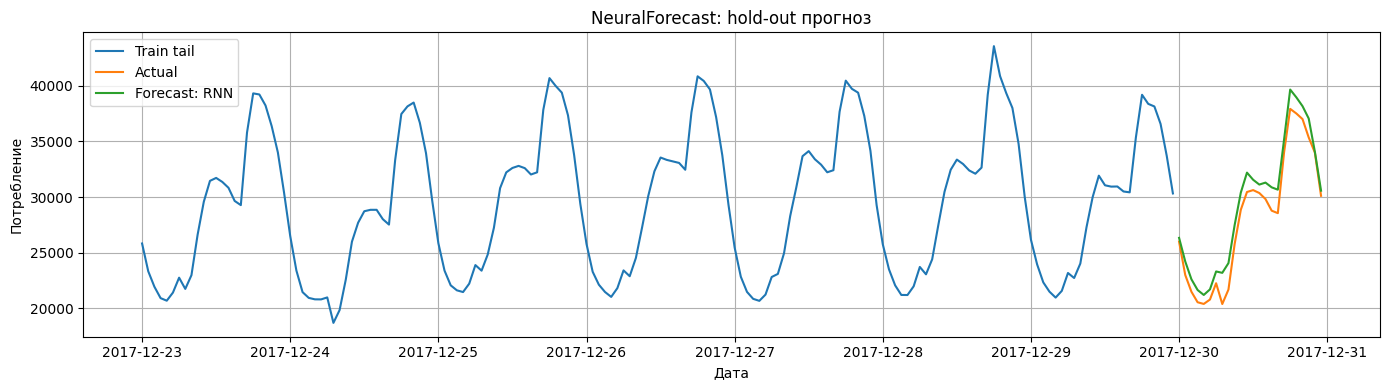

In [37]:
best_dl_model = nf_metrics.iloc[0]["model"]
print("Best DL model:", best_dl_model)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train["ds"].tail(7 * 24), train["y"].tail(7 * 24), label="Train tail")
ax.plot(test["ds"], test["y"], label="Actual")
ax.plot(nf_eval["ds"], nf_eval[best_dl_model], label=f"Forecast: {best_dl_model}")
ax.set_title("NeuralForecast: hold-out прогноз")
ax.set_xlabel("Дата")
ax.set_ylabel("Потребление")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Сравнение ML и DL

Сводим результаты в одну таблицу и выбираем лучшие модели внутри каждого класса

In [38]:
comparison = pd.concat(
    [
        ml_metrics.assign(family="ML"),
        nf_metrics.assign(family="DL"),
    ],
    ignore_index=True,
)

display(comparison.sort_values(["family", "RMSE"]).reset_index(drop=True))

comparison.to_csv(OUT_DIR / "task3_all_metrics.csv", index=False)

best_rows = (
    comparison.sort_values("RMSE")
    .groupby("family", as_index=False)
    .first()
)

display(best_rows)

,model,MAE,RMSE,MAPE_%,family
0,RNN,1328.110161,1471.899106,4.981076,DL
1,LSTM,1488.258355,1635.090325,5.487187,DL
2,NHITS,2694.483208,3048.453626,9.918771,DL
3,LightGBM,730.957009,863.086614,2.678672,ML
4,LinearRegression,743.016215,903.750363,2.634367,ML
5,RandomForest,832.004399,980.518956,3.011592,ML


,family,model,MAE,RMSE,MAPE_%
0,DL,RNN,1328.110161,1471.899106,4.981076
1,ML,LightGBM,730.957009,863.086614,2.678672


## 10. Выявление аномалий во временном ряду

Используем 3 подхода:

1. Rolling z-score — локальные резкие отклонения
2. STL + robust z-score — аномалии после удаления сезонности
3. Isolation Forest — поиск нетипичных комбинаций признаков

In [39]:
series = hourly["y"].reset_index(drop=True)

# 1) Rolling z-score
roll_mean = series.rolling(24).mean()
roll_std = series.rolling(24).std()
roll_z = (series - roll_mean) / roll_std
anomaly_roll = roll_z.abs() > 3

# 2) STL residuals with robust z-score
stl_fit = STL(series, period=24, robust=True).fit()
stl_resid = pd.Series(stl_fit.resid, index=hourly.index)
mad = median_abs_deviation(stl_resid.dropna(), nan_policy="omit")

if mad > 0 and np.isfinite(mad):
    robust_z = 0.6745 * (stl_resid - np.nanmedian(stl_resid)) / mad
else:
    robust_z = pd.Series(np.zeros(len(stl_resid)), index=stl_resid.index)

anomaly_stl = robust_z.abs() > 3.5

# 3) Isolation Forest on lag features
anom_df = hourly.copy()
anom_df["lag1"] = anom_df["y"].shift(1)
anom_df["lag24"] = anom_df["y"].shift(24)
anom_df["lag168"] = anom_df["y"].shift(168)
anom_df["diff1"] = anom_df["y"].diff()
anom_df["hour"] = anom_df["ds"].dt.hour
anom_df["dayofweek"] = anom_df["ds"].dt.dayofweek

feature_cols = ["lag1", "lag24", "lag168", "diff1", "hour", "dayofweek"]
feat = anom_df[feature_cols]
mask = feat.notna().all(axis=1)

iso = IsolationForest(contamination=0.02, random_state=42)
iso.fit(feat.loc[mask])

iso_score = pd.Series(np.nan, index=anom_df.index)
iso_score.loc[mask] = -iso.decision_function(feat.loc[mask])

threshold = np.nanquantile(iso_score[mask], 0.98)
anomaly_iso = iso_score > threshold

anomaly_summary = pd.DataFrame(
    {
        "method": ["Rolling z-score", "STL robust z-score", "IsolationForest"],
        "n_anomalies": [
            int(anomaly_roll.sum()),
            int(anomaly_stl.sum()),
            int(anomaly_iso.sum()),
        ],
    }
)

display(anomaly_summary)
anomaly_summary.to_csv(OUT_DIR / "task3_anomaly_summary.csv", index=False)

,method,n_anomalies
0,Rolling z-score,0
1,STL robust z-score,1626
2,IsolationForest,172


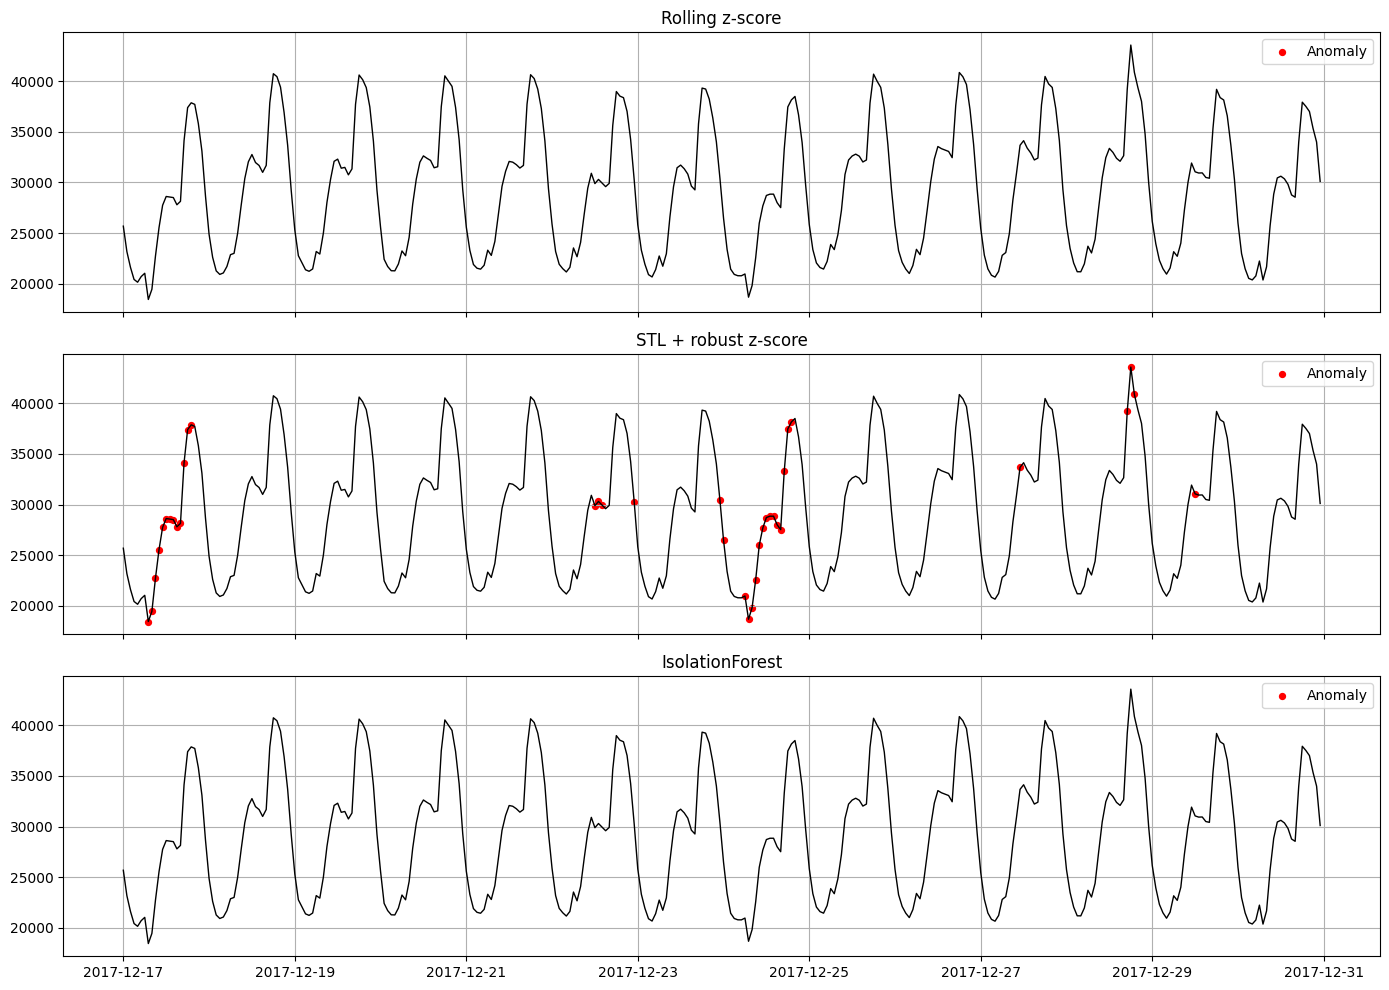

In [40]:
viz = hourly.tail(24 * 14).copy()
viz_idx = viz.index

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Rolling z-score
axes[0].plot(viz["ds"], viz["y"], color="black", linewidth=1)
mask0 = anomaly_roll.loc[viz_idx]
axes[0].scatter(viz.loc[mask0, "ds"], viz.loc[mask0, "y"], color="red", s=18, label="Anomaly")
axes[0].set_title("Rolling z-score")
axes[0].legend()

# STL
axes[1].plot(viz["ds"], viz["y"], color="black", linewidth=1)
mask1 = anomaly_stl.loc[viz_idx]
axes[1].scatter(viz.loc[mask1, "ds"], viz.loc[mask1, "y"], color="red", s=18, label="Anomaly")
axes[1].set_title("STL + robust z-score")
axes[1].legend()

# Isolation Forest
axes[2].plot(viz["ds"], viz["y"], color="black", linewidth=1)
mask2 = anomaly_iso.loc[viz_idx]
axes[2].scatter(viz.loc[mask2, "ds"], viz.loc[mask2, "y"], color="red", s=18, label="Anomaly")
axes[2].set_title("IsolationForest")
axes[2].legend()

plt.tight_layout()
plt.show()

## 11. Итоговая таблица

Сохраняем компактный итог по лучшим моделям и числу аномалий

In [41]:
summary = pd.DataFrame(
    {
        "block": ["ML", "DL"],
        "best_model": [best_ml_model, best_dl_model],
        "best_RMSE": [
            float(ml_metrics.loc[ml_metrics["model"] == best_ml_model, "RMSE"].iloc[0]),
            float(nf_metrics.loc[nf_metrics["model"] == best_dl_model, "RMSE"].iloc[0]),
        ],
    }
)

display(summary)
summary.to_csv(OUT_DIR / "task3_summary.csv", index=False)

,block,best_model,best_RMSE
0,ML,LightGBM,863.086614
1,DL,RNN,1471.899106
